In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("mymoviedb.csv", engine='python', on_bad_lines='skip')

# Clean data
df.dropna(subset=['Title', 'Genre', 'Vote_Average'], inplace=True)
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce')
df['Vote_Average']  = pd.to_numeric(df['Vote_Average'], errors='coerce')
df['Vote_Count']    = pd.to_numeric(df['Vote_Count'],   errors='coerce')
df['Popularity']    = pd.to_numeric(df['Popularity'],   errors='coerce')
df['Year']          = df['Release_Date'].dt.year

print("Dataset loaded! Shape:", df.shape)
df.head()

Dataset loaded! Shape: (9826, 10)


,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url,Year
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...,2021
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...,2022
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...,2022
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...,2021
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...,2021


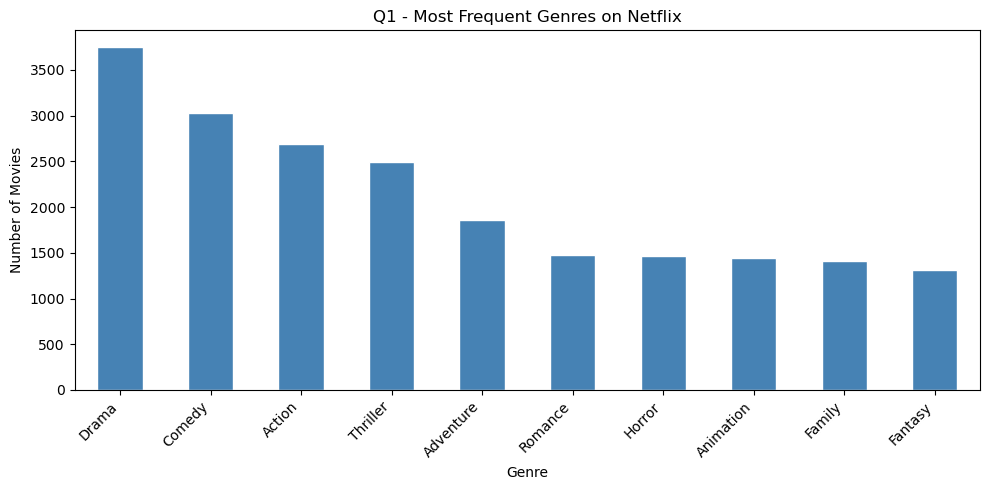

✅ Most frequent genre: Drama with 3744 movies


In [11]:
# Split genres since one movie can have multiple
genres = df['Genre'].dropna().str.split(', ').explode()
top_genre = genres.value_counts()

plt.figure(figsize=(10, 5))
top_genre.head(10).plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Q1 - Most Frequent Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("✅ Most frequent genre:", top_genre.idxmax(), "with", top_genre.max(), "movies")

In [12]:
idx = df['Vote_Average'].idxmax()
top_voted = df.loc[idx, ['Title', 'Vote_Average', 'Vote_Count', 'Genre']]

print("✅ Highest Vote Average Movie:")
print(top_voted)

✅ Highest Vote Average Movie:
Title           Kung Fu Master Huo Yuanjia
Vote_Average                          10.0
Vote_Count                               1
Genre                        Action, Drama
Name: 9401, dtype: object


In [13]:
idx = df['Popularity'].idxmax()
most_popular = df.loc[idx, ['Title', 'Popularity', 'Genre']]

print("✅ Most Popular Movie:")
print(most_popular)

✅ Most Popular Movie:
Title                    Spider-Man: No Way Home
Popularity                              5083.954
Genre         Action, Adventure, Science Fiction
Name: 0, dtype: object


In [14]:
idx = df['Popularity'].idxmin()
least_popular = df.loc[idx, ['Title', 'Popularity', 'Genre']]

print("✅ Least Popular Movie:")
print(least_popular)

✅ Least Popular Movie:
Title         The United States vs. Billie Holiday
Popularity                                  13.354
Genre                        Music, Drama, History
Name: 9835, dtype: object


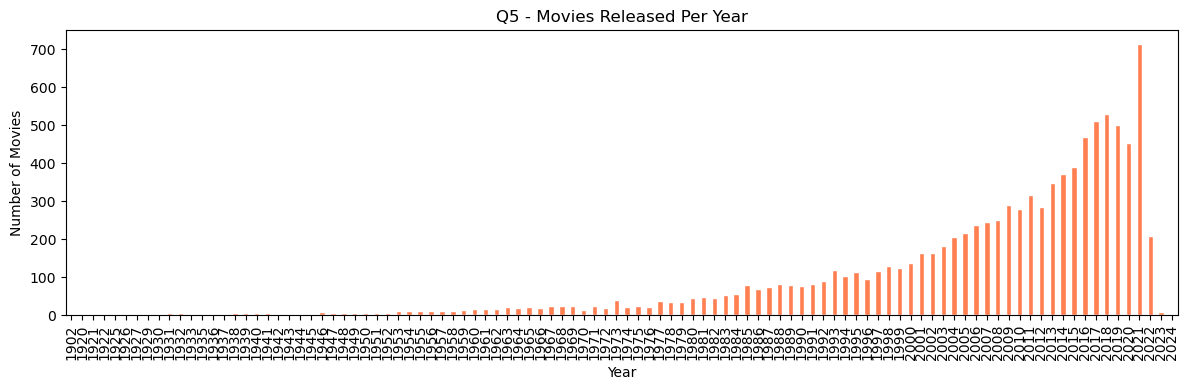

✅ Year with most movies: 2021 with 714 movies


In [15]:
yearly = df['Year'].value_counts().sort_index()

plt.figure(figsize=(12, 4))
yearly.plot(kind='bar', color='coral', edgecolor='white')
plt.title('Q5 - Movies Released Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.show()

print("✅ Year with most movies:", int(df['Year'].value_counts().idxmax()),
      "with", df['Year'].value_counts().max(), "movies")

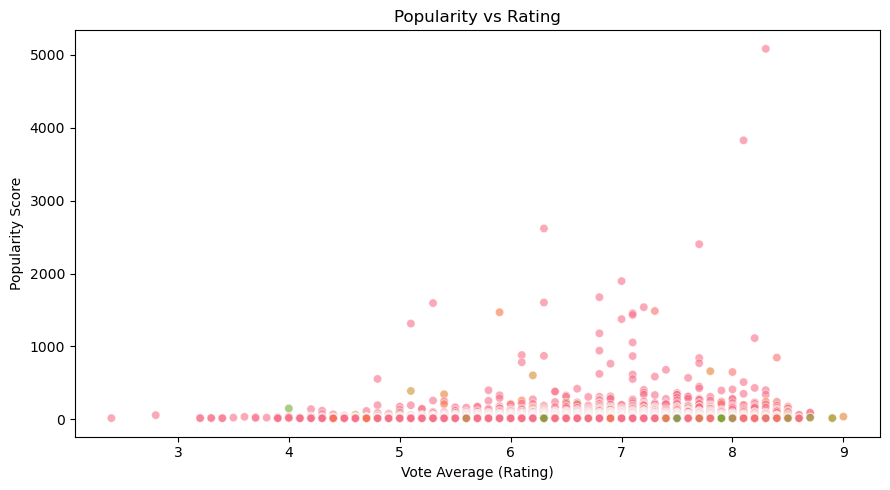

In [25]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df[df['Vote_Count'] >= 100],
                x='Vote_Average', y='Popularity',
                hue='Original_Language', legend=False, alpha=0.6)
plt.title('Popularity vs Rating')
plt.xlabel('Vote Average (Rating)')
plt.ylabel('Popularity Score')
plt.tight_layout()
plt.show()

C:\Users\RUSHI BHATT\AppData\Local\Temp\ipykernel_26432\2906277782.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_voted, x='Vote_Count', y='Title', palette='Oranges_r')


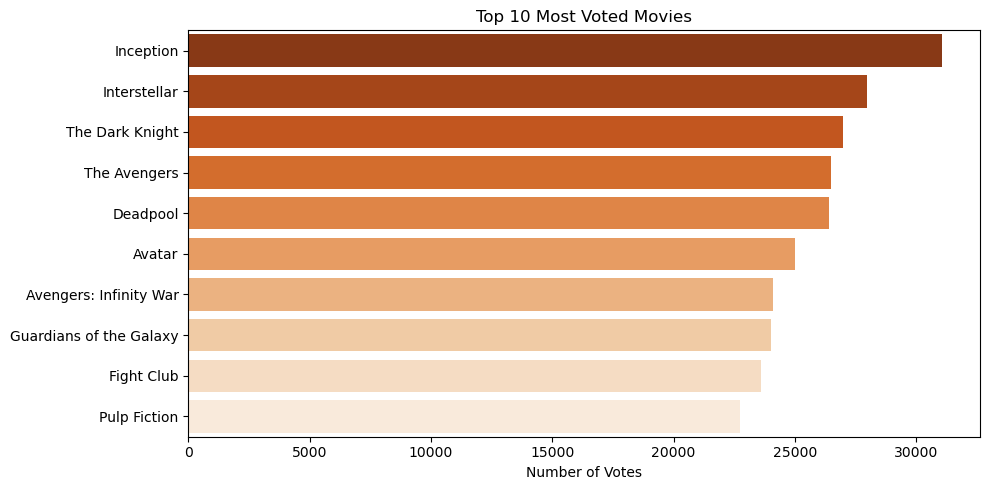

In [23]:
top_voted = df.nlargest(10, 'Vote_Count')[['Title','Vote_Count']]

plt.figure(figsize=(10, 5))
sns.barplot(data=top_voted, x='Vote_Count', y='Title', palette='Oranges_r')
plt.title('Top 10 Most Voted Movies')
plt.xlabel('Number of Votes')
plt.ylabel('')
plt.tight_layout()
plt.show()

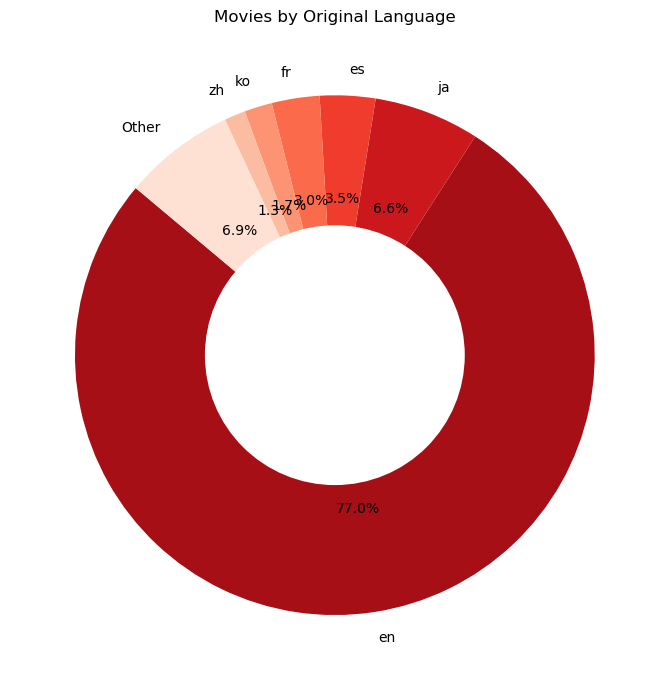

In [36]:
lang = df['Original_Language'].value_counts()
top_langs = lang.head(6)
top_langs['Other'] = lang[6:].sum()

plt.figure(figsize=(7, 7))
plt.pie(top_langs, labels=top_langs.index, autopct='%1.1f%%',
        startangle=140, colors=sns.color_palette('Reds_r', len(top_langs)))
centre = plt.Circle((0,0), 0.5, fc='white')
plt.gca().add_artist(centre)
plt.title('Movies by Original Language')
plt.tight_layout()
plt.show()